In [1]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("amineipad/bitcoin-prices-dataset")

print("Path to dataset files:", path)
import

100%|██████████| 163k/163k [00:00<00:00, 50.9MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/amineipad/bitcoin-prices-dataset/versions/1


In [9]:
import os
os.listdir(path)

['bitcoin.csv']

In [10]:
df_path = os.path.join(path, 'bitcoin.csv')

In [18]:
print(df.dtypes)

Date              object
Open             float64
High             float64
Low              float64
Close            float64
Volume           float64
PriceCategory     object
dtype: object


In [19]:
# Convert Date to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Ensure all price columns are numeric (forcing errors to NaN just in case)
cols_to_numeric = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']
for col in cols_to_numeric:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print(df.dtypes)

Date             datetime64[ns]
Open                    float64
High                    float64
Low                     float64
Close                   float64
Volume                  float64
PriceCategory            object
dtype: object


In [20]:
df.isna().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Volume,0
PriceCategory,0


In [21]:
df_missing = df.copy()

# Introduce NaNs in the first 10 rows of the 'Close' column
df_missing.loc[0:9, 'Close'] = np.nan
print(df_missing.isna().sum())
df_missing.head(12)

Date              0
Open              0
High              0
Low               0
Close            10
Volume            0
PriceCategory     0
dtype: int64


,Date,Open,High,Low,Close,Volume,PriceCategory
0,2010-01-01,0.3,0.303428,0.295510,NaN,715.8,Low
1,2010-01-02,0.3,0.304377,0.299459,NaN,2028.3,Low
2,2010-01-03,0.3,0.303736,0.295858,NaN,273.0,Low
3,2010-01-04,0.3,0.303406,0.298489,NaN,1452.0,Low
4,2010-01-05,0.3,0.302715,0.296330,NaN,1002.6,Low
5,2010-01-06,0.3,0.303982,0.298127,NaN,872.7,Low
6,2010-01-07,0.3,0.302794,0.299572,NaN,421.2,Low
7,2010-01-08,0.3,0.305383,0.295792,NaN,1030.5,Low
8,2010-01-09,0.3,0.305793,0.297143,NaN,2379.9,Low
9,2010-01-10,0.3,0.302486,0.295572,NaN,310.5,Low


In [22]:
df_removed = df_missing.dropna()
print("Original shape: ", df.shape)
print("After dropping NAs: ", df_removed.shape)

Original shape:  (5883, 7)
After dropping NAs:  (5873, 7)


In [23]:
df_imputed_mean = df_missing.copy()
df_imputed_mean['Close'].fillna(df_imputed_mean['Close'].mean(), inplace=True)

df_imputed_mean.head(12)

/tmp/ipykernel_162/1120842843.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_imputed_mean['Close'].fillna(df_imputed_mean['Close'].mean(), inplace=True)


,Date,Open,High,Low,Close,Volume,PriceCategory
0,2010-01-01,0.3,0.303428,0.295510,21773.790616,715.8,Low
1,2010-01-02,0.3,0.304377,0.299459,21773.790616,2028.3,Low
2,2010-01-03,0.3,0.303736,0.295858,21773.790616,273.0,Low
3,2010-01-04,0.3,0.303406,0.298489,21773.790616,1452.0,Low
4,2010-01-05,0.3,0.302715,0.296330,21773.790616,1002.6,Low
5,2010-01-06,0.3,0.303982,0.298127,21773.790616,872.7,Low
6,2010-01-07,0.3,0.302794,0.299572,21773.790616,421.2,Low
7,2010-01-08,0.3,0.305383,0.295792,21773.790616,1030.5,Low
8,2010-01-09,0.3,0.305793,0.297143,21773.790616,2379.9,Low
9,2010-01-10,0.3,0.302486,0.295572,21773.790616,310.5,Low


In [24]:
df_imputed_median = df_missing.copy()
df_imputed_median['Close'].fillna(df_imputed_median['Close'].median(), inplace=True)

df_imputed_median.head(12)

/tmp/ipykernel_162/3823865369.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_imputed_median['Close'].fillna(df_imputed_median['Close'].median(), inplace=True)


,Date,Open,High,Low,Close,Volume,PriceCategory
0,2010-01-01,0.3,0.303428,0.295510,7193.6,715.8,Low
1,2010-01-02,0.3,0.304377,0.299459,7193.6,2028.3,Low
2,2010-01-03,0.3,0.303736,0.295858,7193.6,273.0,Low
3,2010-01-04,0.3,0.303406,0.298489,7193.6,1452.0,Low
4,2010-01-05,0.3,0.302715,0.296330,7193.6,1002.6,Low
5,2010-01-06,0.3,0.303982,0.298127,7193.6,872.7,Low
6,2010-01-07,0.3,0.302794,0.299572,7193.6,421.2,Low
7,2010-01-08,0.3,0.305383,0.295792,7193.6,1030.5,Low
8,2010-01-09,0.3,0.305793,0.297143,7193.6,2379.9,Low
9,2010-01-10,0.3,0.302486,0.295572,7193.6,310.5,Low


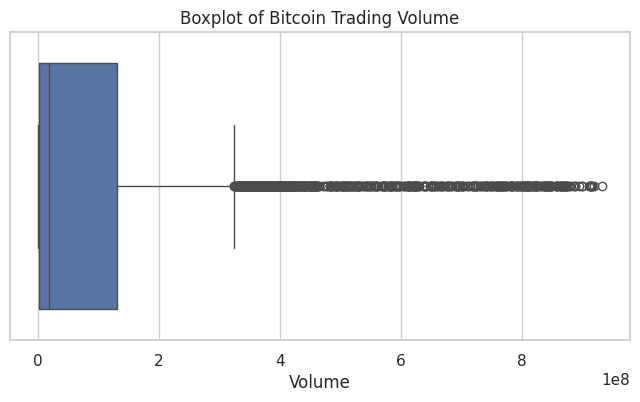

In [25]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['Volume'])
plt.title("Boxplot of Bitcoin Trading Volume")
plt.show()

In [29]:
Q1 = df['Volume'].quantile(0.25)
Q3 = df['Volume'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Volume'] < lower) | (df['Volume'] > upper)]
print(f"Number of outlier days detected: {len(outliers)}")
outliers.head()

Number of outlier days detected: 687


,Date,Open,High,Low,Close,Volume,PriceCategory
4018,2021-01-01,29001.72,47115.833155,28864.157143,46306.45,4.309741e+08,High
4019,2021-01-02,46306.45,46571.051201,45759.864720,46306.45,3.308133e+08,High
4021,2021-01-04,46306.45,47170.792814,45763.489729,46306.45,4.334284e+08,High
4024,2021-01-07,46306.45,46845.249968,45663.121692,46306.45,4.354659e+08,High
4028,2021-01-11,46306.45,46626.777268,46095.818386,46306.45,3.908264e+08,High


In [30]:
lower_cap = df['Volume'].quantile(0.05)
upper_cap = df['Volume'].quantile(0.95)

df_capped = df.copy()
df_capped['Volume'] = df_capped['Volume'].clip(lower_cap, upper_cap)

print("Max volume before capping:", df['Volume'].max())
print("Max volume after capping:", df_capped['Volume'].max())

Max volume before capping: 932516845.2
Max volume after capping: 540760814.9849998


In [31]:
from sklearn.preprocessing import MinMaxScaler

scaler_minmax = MinMaxScaler()
df_minmax = df[['Close', 'Volume']].copy()
# Drop NAs for scaling if any exist
df_minmax = df_minmax.dropna()

df_minmax[['Close', 'Volume']] = scaler_minmax.fit_transform(df_minmax)
df_minmax.head()

,Close,Volume
0,0.0,7.351074e-07
1,0.0,2.142589e-06
2,0.0,2.602634e-07
3,0.0,1.524584e-06
4,0.0,1.042662e-06


In [34]:
from sklearn.preprocessing import StandardScaler

scaler_std = StandardScaler()
df_standardized = df[['Close', 'Volume']].copy().dropna()

df_standardized[['Close', 'Volume']] = scaler_std.fit_transform(df_standardized)
df_standardized.head()

,Close,Volume
0,-0.721725,-0.587759
1,-0.721725,-0.587752
2,-0.721725,-0.587762
3,-0.721725,-0.587755
4,-0.721725,-0.587758


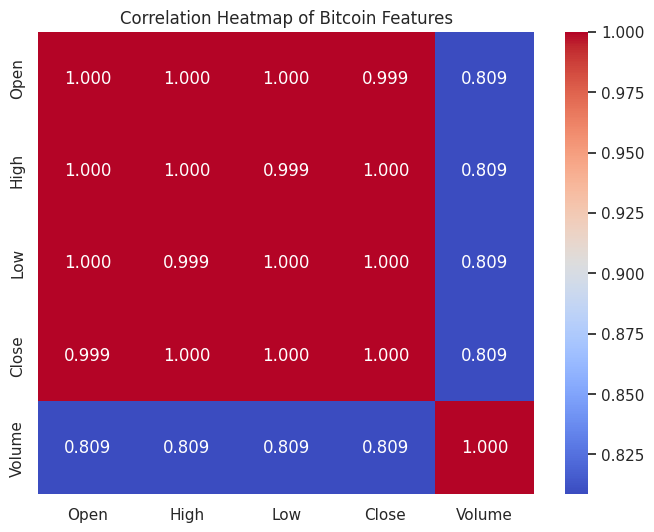

In [39]:
features_for_pca = ['Open', 'High', 'Low', 'Close', 'Volume']
df_features = df[features_for_pca].dropna()

plt.figure(figsize=(8,6))
sns.heatmap(df_features.corr(), annot=True, cmap="coolwarm", fmt=".3f")
plt.title("Correlation Heatmap of Bitcoin Features")
plt.show()

In [37]:
from sklearn.decomposition import PCA

# Standardize the 4 price columns first (PCA is highly sensitive to scale)
price_features = ['Open', 'High', 'Low', 'Close']
X_prices = df[price_features].dropna()
X_scaled = StandardScaler().fit_transform(X_prices)

# Apply PCA
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print(f"Total variance captured by 2 components: {sum(pca.explained_variance_ratio_):.4f}")

Explained Variance Ratio: [9.99719729e-01 2.04354638e-04]
Total variance captured by 2 components: 0.9999


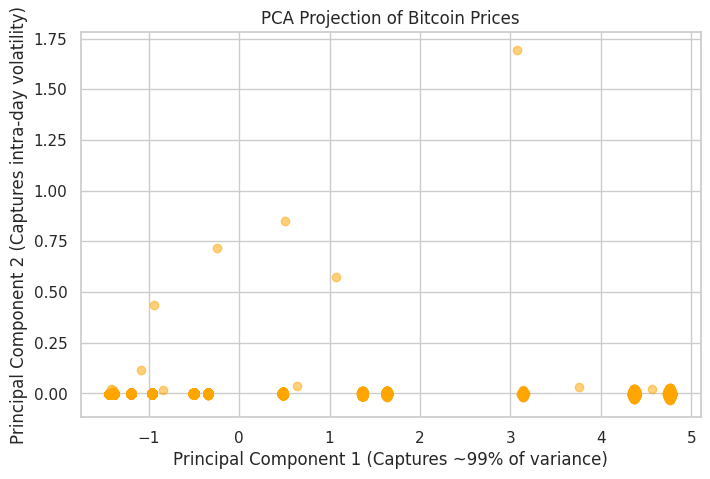

In [38]:
plt.figure(figsize=(8,5))
plt.scatter(principal_components[:, 0], principal_components[:, 1], alpha=0.5, c='orange')
plt.title("PCA Projection of Bitcoin Prices")
plt.xlabel("Principal Component 1 (Captures ~99% of variance)")
plt.ylabel("Principal Component 2 (Captures intra-day volatility)")
plt.show()